# LongDocURL — Answer 覆盖率统计

**目标：** 统计用 answer 文本在 evidence page 内精确匹配，能定位到 chunk 的比例。  
同时统计：answer 长度分布、问题类型分布、表格/图片问题占比。

> 直接在 Colab / 本地 Jupyter 运行，Cell 顺序执行即可。


## 0. 安装依赖

In [1]:
!pip install datasets rank_bm25 matplotlib pandas -q


## 1. 加载数据集 & 探查结构

In [4]:
# 挂载 Google Drive
from google.colab import drive
drive.mount('/content/drive')

from datasets import load_dataset
import os

SAVE_PATH = "/content/drive/MyDrive/datasets/LongDocURL"

if os.path.exists(SAVE_PATH):
    # 已存在，直接从本地加载
    from datasets import load_from_disk
    ds = load_from_disk(SAVE_PATH)
    print(f"Loaded from Drive: {len(ds)} rows")
else:
    # 第一次：下载并保存
    print("Downloading from HuggingFace...")
    ds = load_dataset("dengchao/LongDocURL", split="train")
    ds.save_to_disk(SAVE_PATH)
    print(f"Saved to Drive: {len(ds)} rows")

Mounted at /content/drive


png_files_p1.tar.gz:   0%|          | 0.00/2.99G [00:00<?, ?B/s]

png_files_p2.tar.gz:   0%|          | 0.00/2.11G [00:00<?, ?B/s]

Generating train split:   0%|          | 0/34309 [00:00<?, ? examples/s]

Saving the dataset (0/6 shards):   0%|          | 0/34309 [00:00<?, ? examples/s]

Saved to Drive: 34309 rows


In [5]:
# 打印前 3 条，确认字段名和内容
for i in range(min(3, len(ds))):
    row = ds[i]
    print(f"{'='*60}  Sample {i}  {'='*60}")
    for k, v in row.items():
        if hasattr(v, 'size'):          # PIL Image
            print(f"  [{k}]  Image {v.size}")
        elif isinstance(v, list):
            print(f"  [{k}]  list[{len(v)}]  first={repr(str(v[0])[:120]) if v else '[]'}")
        elif isinstance(v, str):
            print(f"  [{k}]  {repr(v[:200])}")
        else:
            print(f"  [{k}]  {type(v).__name__} = {repr(str(v)[:100])}")
    print()


============================================================  Sample 0  ============================================================
  [__key__]  'mnt/achao/Downloads/ccpdf_zip/4000-4999/4118/4118517'
  [__url__]  '/root/.cache/huggingface/hub/datasets--dengchao--LongDocURL/snapshots/5c96dbe9055f0382f207228d0f84b77206b6bcb6/pdf_files.tar.gz'
  [pdf]  bytes = "b'%PDF-1.4\\r%\\xe2\\xe3\\xcf\\xd3\\r\\n203 0 obj<</H[596 657]/Linearized 1/E 54648/L 309748/N 77/O 207/T 3"

============================================================  Sample 1  ============================================================
  [__key__]  'mnt/achao/Downloads/ccpdf_zip/4000-4999/4176/4176533'
  [__url__]  '/root/.cache/huggingface/hub/datasets--dengchao--LongDocURL/snapshots/5c96dbe9055f0382f207228d0f84b77206b6bcb6/pdf_files.tar.gz'
  [pdf]  bytes = "b'%PDF-1.6\\r%\\xe2\\xe3\\xcf\\xd3\\r\\n706 0 obj\\r<</Linearized 1/L 8465645/O 708/E 568983/N 102/T 8463903"

=======================================================

In [6]:
# 下载完整 QA 标注（带 subtask 分类，信息更全）
!wget "https://huggingface.co/datasets/dengchao/LongDocURL/resolve/main/LongDocURL_public_with_subtask_category.jsonl" -O LongDocURL.jsonl

# 保存到 Drive
from google.colab import drive
drive.mount('/content/drive')
!cp LongDocURL.jsonl "/content/drive/MyDrive/datasets/LongDocURL.jsonl"

# 加载验证
import json
with open("LongDocURL.jsonl") as f:
    data = [json.loads(line) for line in f]

print(f"总条数: {len(data)}")
print(f"字段: {list(data[0].keys())}")

--2026-03-23 07:08:18--  https://huggingface.co/datasets/dengchao/LongDocURL/resolve/main/LongDocURL_public_with_subtask_category.jsonl
Resolving huggingface.co (huggingface.co)... 13.35.202.34, 13.35.202.97, 13.35.202.121, ...
Connecting to huggingface.co (huggingface.co)|13.35.202.34|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: /api/resolve-cache/datasets/dengchao/LongDocURL/5c96dbe9055f0382f207228d0f84b77206b6bcb6/LongDocURL_public_with_subtask_category.jsonl?%2Fdatasets%2Fdengchao%2FLongDocURL%2Fresolve%2Fmain%2FLongDocURL_public_with_subtask_category.jsonl=&etag=%22c7e90195e29c7e00d6be977da6dd2d4374003c62%22 [following]
--2026-03-23 07:08:18--  https://huggingface.co/api/resolve-cache/datasets/dengchao/LongDocURL/5c96dbe9055f0382f207228d0f84b77206b6bcb6/LongDocURL_public_with_subtask_category.jsonl?%2Fdatasets%2Fdengchao%2FLongDocURL%2Fresolve%2Fmain%2FLongDocURL_public_with_subtask_category.jsonl=&etag=%22c7e90195e29c7e00d6be977da6dd

In [16]:
import json, re, string
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

## 3. 工具函数

In [8]:
def normalize(text: str) -> str:
    text = str(text).lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    return re.sub(r"\s+", " ", text).strip()

def answer_in_text_strict(answer, text: str) -> bool:
    """严格子串匹配（忽略大小写）"""
    return str(answer).lower().strip() in text.lower()

def answer_in_text_loose(answer, text: str) -> bool:
    """宽松匹配：去标点+空白后做子串检查"""
    return normalize(str(answer)) in normalize(text)

def token_len(text) -> int:
    return len(str(text).strip().split())

print(" 工具函数就绪")


 工具函数就绪


In [9]:
df = pd.DataFrame([{
    "question_id":   d["question_id"],
    "answer":        str(d["answer"]),
    "answer_format": d.get("answer_format", "unknown"),
    "task_tag":      d.get("task_tag", "unknown"),
    "subTask":       d.get("subTask", "unknown"),
    "evidence_sources": d.get("evidence_sources", []),
    "evidence_pages":   d.get("evidence_pages", []),
    "detailed_evidences": str(d.get("detailed_evidences", "")),
    "n_evidence_pages": len(d.get("evidence_pages", [])),
    "answer_token_len": token_len(d["answer"]),
    "has_figure":    "Figure" in d.get("evidence_sources", []),
    "has_table":     "Table"  in d.get("evidence_sources", []),
    "has_text":      "Text"   in d.get("evidence_sources", []),
    "has_layout":    "Layout" in d.get("evidence_sources", []),
} for d in data])

print(f"=== 总样本数: {len(df)} ===\n")

print("── answer_format 分布 ──")
print(df["answer_format"].value_counts().to_string())
print()

print("── task_tag 分布 ──")
print(df["task_tag"].value_counts().to_string())
print()

print("── evidence_sources 各类出现频率（一条可含多类）──")
for src in ["Text", "Layout", "Figure", "Table"]:
    col = f"has_{src.lower()}"
    n = df[col].sum()
    print(f"  {src:8s}: {n:5d}  ({n/len(df)*100:.1f}%)")
print()

print("── evidence pages 数量分布 ──")
print(df["n_evidence_pages"].value_counts().sort_index().to_string())


=== 总样本数: 2325 ===

── answer_format 分布 ──
answer_format
String     941
List       757
Integer    431
Float      185
None        11

── task_tag 分布 ──
task_tag
Understanding    1243
Locating          695
Reasoning         387

── evidence_sources 各类出现频率（一条可含多类）──
  Text    :   994  (42.8%)
  Layout  :   779  (33.5%)
  Figure  :   548  (23.6%)
  Table   :   871  (37.5%)

── evidence pages 数量分布 ──
n_evidence_pages
0        2
1     1093
2      914
3      183
4       68
5       21
6        9
7        9
8        9
9        2
12       1
13       1
16       4
17       3
26       2
27       1
28       1
30       2


## 4. Answer 长度分布

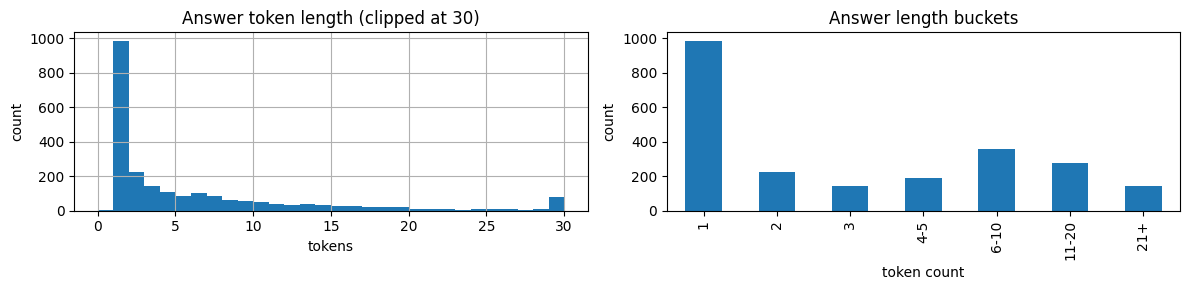


── 分档统计 ──
len_bin
1        986
2        223
3        141
4-5      192
6-10     360
11-20    278
21+      144

答案 token ≤ 3 的比例: 58.1%
答案 token ≤ 1 的比例: 42.5%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# 直方图
df["answer_token_len"].clip(upper=30).hist(bins=30, ax=axes[0])
axes[0].set_title("Answer token length (clipped at 30)")
axes[0].set_xlabel("tokens"); axes[0].set_ylabel("count")

# 按 format 分桶
bins   = [0,1,2,3,5,10,20,999]
labels = ["1","2","3","4-5","6-10","11-20","21+"]
df["len_bin"] = pd.cut(df["answer_token_len"], bins=bins, labels=labels)
df["len_bin"].value_counts().sort_index().plot(kind="bar", ax=axes[1])
axes[1].set_title("Answer length buckets")
axes[1].set_xlabel("token count"); axes[1].set_ylabel("count")

plt.tight_layout(); plt.show()

print("\n── 分档统计 ──")
print(df["len_bin"].value_counts().sort_index().to_string())
print(f"\n答案 token ≤ 3 的比例: {(df['answer_token_len'] <= 3).mean()*100:.1f}%")
print(f"答案 token ≤ 1 的比例: {(df['answer_token_len'] <= 1).mean()*100:.1f}%")


## 6. Answer 精确匹配覆盖率统计

**逻辑：**
1. 取该条样本的 evidence page（页码）
2. 在这些页的文本中搜索 answer 是否出现（子串）
3. 统计"能匹配到"的比例

> 如果 `page_texts` 字段不存在，此 cell 会提示跳过。


In [11]:
results = []
for d in data:
    answer   = str(d["answer"])
    evidence = str(d.get("detailed_evidences", ""))
    ev_srcs  = d.get("evidence_sources", [])
    fmt      = d.get("answer_format", "unknown")

    strict = answer_in_text_strict(answer, evidence)
    loose  = answer_in_text_loose(answer, evidence)
    tok    = token_len(answer)

    results.append({
        "strict":           strict,
        "loose":            loose,
        "token_len":        tok,
        "answer_format":    fmt,
        "has_figure":       "Figure" in ev_srcs,
        "has_table":        "Table"  in ev_srcs,
        "text_only":        ev_srcs == ["Text"],
        "evidence_sources": str(ev_srcs),
    })

res = pd.DataFrame(results)
total = len(res)

print(f"总样本: {total}")
print(f"严格匹配覆盖率: {res['strict'].mean()*100:.1f}%  ({res['strict'].sum()})")
print(f"宽松匹配覆盖率: {res['loose'].mean()*100:.1f}%  ({res['loose'].sum()})")
print()

print("── 按 answer_format 拆分（严格匹配）──")
g = res.groupby("answer_format")["strict"].agg(["sum","count","mean"])
g.columns = ["matched","total","coverage"]
g["coverage"] = g["coverage"].map("{:.1%}".format)
print(g.sort_values("total", ascending=False).to_string())
print()

print("── 按 evidence_source 类型拆分（严格匹配）──")
for label, mask in [
    ("Text only",           res["text_only"]),
    ("Contains Figure",     res["has_figure"]),
    ("Contains Table",      res["has_table"]),
    ("Non-text (Fig/Tab)",  res["has_figure"] | res["has_table"]),
]:
    sub = res[mask]
    if len(sub) == 0: continue
    print(f"  {label:25s}: {sub['strict'].mean()*100:.1f}%  (n={len(sub)})")


总样本: 2325
严格匹配覆盖率: 35.6%  (827)
宽松匹配覆盖率: 44.7%  (1040)

── 按 answer_format 拆分（严格匹配）──
               matched  total coverage
answer_format                         
String             380    941    40.4%
List                12    757     1.6%
Integer            287    431    66.6%
Float              147    185    79.5%
None                 1     11     9.1%

── 按 evidence_source 类型拆分（严格匹配）──
  Text only                : 46.6%  (n=487)
  Contains Figure          : 39.2%  (n=548)
  Contains Table           : 32.0%  (n=871)
  Non-text (Fig/Tab)       : 38.4%  (n=1254)


/tmp/ipykernel_1166/3542526253.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g2 = res.groupby("len_bin")["strict"].agg(["sum","count","mean"])


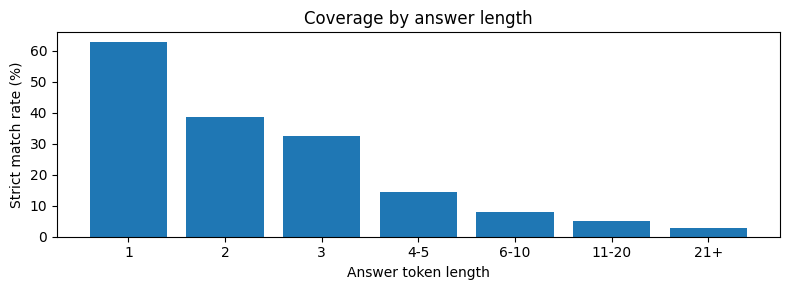

         matched  total coverage
len_bin                         
1            619    986    62.8%
2             86    223    38.6%
3             46    141    32.6%
4-5           28    192    14.6%
6-10          29    360     8.1%
11-20         14    278     5.0%
21+            4    144     2.8%


In [12]:
bins   = [0,1,2,3,5,10,20,999]
labels = ["1","2","3","4-5","6-10","11-20","21+"]
res["len_bin"] = pd.cut(res["token_len"], bins=bins, labels=labels)

g2 = res.groupby("len_bin")["strict"].agg(["sum","count","mean"])
g2.columns = ["matched","total","coverage"]

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(len(g2)), g2["coverage"]*100)
ax.set_xticks(range(len(g2)))
ax.set_xticklabels(g2.index)
ax.set_xlabel("Answer token length"); ax.set_ylabel("Strict match rate (%)")
ax.set_title("Coverage by answer length")
plt.tight_layout(); plt.show()

g2["coverage"] = g2["coverage"].map("{:.1%}".format)
print(g2.to_string())


In [13]:
print("=== 训练数据可用性估计 ===\n")

# 策略1：只用 strict match 样本
strict_usable = res["strict"].sum()
print(f"策略1 - 严格匹配可用样本: {strict_usable} / {total}  ({strict_usable/total*100:.1f}%)")

# 策略2：loose match
loose_usable = res["loose"].sum()
print(f"策略2 - 宽松匹配可用样本: {loose_usable} / {total}  ({loose_usable/total*100:.1f}%)")

# 策略3：过滤掉 answer token ≤ 3 且 non-text 的（噪声最高的子集）
noisy_mask = (res["token_len"] <= 3) | (res["has_figure"] | res["has_table"])
clean_mask  = ~noisy_mask
print(f"\n过滤掉短answer + 非文本后剩余样本: {clean_mask.sum()} / {total}  ({clean_mask.sum()/total*100:.1f}%)")
print(f"  其中严格匹配率: {res[clean_mask]['strict'].mean()*100:.1f}%")

print(f"\n── 决策参考 ──")
print(f"  覆盖率 ≥ 60%  → 可直接用精确匹配构建训练数据")
print(f"  覆盖率 40-60% → 需用 answer sentence 策略 + 接受噪声")
print(f"  覆盖率 < 40%  → 必须引入 VLM 打分补充正样本")


=== 训练数据可用性估计 ===

策略1 - 严格匹配可用样本: 827 / 2325  (35.6%)
策略2 - 宽松匹配可用样本: 1040 / 2325  (44.7%)

过滤掉短answer + 非文本后剩余样本: 499 / 2325  (21.5%)
  其中严格匹配率: 11.0%

── 决策参考 ──
  覆盖率 ≥ 60%  → 可直接用精确匹配构建训练数据
  覆盖率 40-60% → 需用 answer sentence 策略 + 接受噪声
  覆盖率 < 40%  → 必须引入 VLM 打分补充正样本


In [18]:
subtasks = [str(d.get("subTask", "unknown")) for d in data]
cnt = Counter(subtasks)
print("subTask 分布：")
for t, n in cnt.most_common():
    print(f"  {str(t):45s}  {n:5d}  ({n/len(data)*100:.1f}%)")

subTask 分布：
  ['SP_Table_Understanding']                       241  (10.4%)
  ['Figure_Table_Locating']                        231  (9.9%)
  ['MP_Text_Understanding']                        230  (9.9%)
  ['Cross_Title_Locating']                         201  (8.6%)
  ['SP_Text_Understanding']                        176  (7.6%)
  ['Para_Title_Locating']                          137  (5.9%)
  ['Cross_Table_Locating']                         126  (5.4%)
  ['SP_Table_Reasoning']                            92  (4.0%)
  ['MP_Text_Understanding', 'MP_Figure_Understanding']     91  (3.9%)
  ['MP_Text_Understanding', 'MP_Layout_Understanding']     82  (3.5%)
  ['SP_Figure_Understanding']                       60  (2.6%)
  ['MP_Text_Reasoning']                             58  (2.5%)
  ['MP_Table_Understanding']                        57  (2.5%)
  ['MP_Table_Reasoning']                            53  (2.3%)
  ['MP_Layout_Understanding']                       44  (1.9%)
  ['SP_Layout_Understanding'

In [19]:
import os

SAVE_DIR = "/content/drive/MyDrive/datasets/"  # 改成你的路径
os.makedirs(SAVE_DIR, exist_ok=True)

# 保存带统计字段的完整 DataFrame
out_path = os.path.join(SAVE_DIR, "longdocurl_coverage_stats.csv")
res["answer"]   = [d["answer"] for d in data]
res["question"] = [d["question"] for d in data]
res.to_csv(out_path, index=False)
print(f"已保存: {out_path}")

# 打印最终 summary
print(f"\n=== FINAL SUMMARY ===")
print(f"总样本数            : {total}")
print(f"严格匹配覆盖率      : {res['strict'].mean()*100:.1f}%")
print(f"宽松匹配覆盖率      : {res['loose'].mean()*100:.1f}%")
print(f"answer ≤ 3 tokens   : {(res['token_len'] <= 3).mean()*100:.1f}%")
print(f"含 Figure/Table     : {(res['has_figure'] | res['has_table']).mean()*100:.1f}%")


已保存: /content/drive/MyDrive/datasets/longdocurl_coverage_stats.csv

=== FINAL SUMMARY ===
总样本数            : 2325
严格匹配覆盖率      : 35.6%
宽松匹配覆盖率      : 44.7%
answer ≤ 3 tokens   : 58.1%
含 Figure/Table     : 53.9%


In [20]:
# Cell A: 可用样本细拆
strict_data = [d for d, r in zip(data, res.to_dict("records")) if r["strict"]]
print(f"严格匹配成功: {len(strict_data)}\n")

from itertools import chain
from collections import Counter

fmt_cnt  = Counter(d["answer_format"] for d in strict_data)
src_cnt  = Counter(chain.from_iterable(d["evidence_sources"] for d in strict_data))
task_cnt = Counter(d["task_tag"] for d in strict_data)

print("── answer_format ──")
for k,v in fmt_cnt.most_common():
    print(f"  {k:12s}: {v:4d}  (占可用{v/len(strict_data)*100:.1f}%  占总体{v/len(data)*100:.1f}%)")

print("\n── evidence_sources ──")
for k,v in src_cnt.most_common():
    print(f"  {k:8s}: {v:4d}  ({v/len(strict_data)*100:.1f}%)")

print("\n── task_tag ──")
for k,v in task_cnt.most_common():
    print(f"  {k:15s}: {v:4d}  ({v/len(strict_data)*100:.1f}%)")

严格匹配成功: 827

── answer_format ──
  String      :  380  (占可用45.9%  占总体16.3%)
  Integer     :  287  (占可用34.7%  占总体12.3%)
  Float       :  147  (占可用17.8%  占总体6.3%)
  List        :   12  (占可用1.5%  占总体0.5%)
  None        :    1  (占可用0.1%  占总体0.0%)

── evidence_sources ──
  Text    :  415  (50.2%)
  Table   :  279  (33.7%)
  Figure  :  221  (26.7%)
  Layout  :  155  (18.7%)
  Others  :    6  (0.7%)

── task_tag ──
  Understanding  :  592  (71.6%)
  Reasoning      :  234  (28.3%)
  Locating       :    1  (0.1%)


In [21]:
# Cell B: 失败原因分类
failed_data = [d for d, r in zip(data, res.to_dict("records")) if not r["strict"]]
reason_counts = Counter()
examples = {}

for d in failed_data:
    answer  = str(d["answer"])
    tok_len = len(answer.strip().split())
    srcs    = d["evidence_sources"]
    fmt     = d["answer_format"]

    if fmt == "List":
        reason = "List answer"
    elif tok_len <= 1:
        reason = "Single token/number"
    elif tok_len <= 3 and ("Figure" in srcs or "Table" in srcs):
        reason = "Short + non-text source"
    elif set(srcs) == {"Figure"}:
        reason = "Figure only"
    elif set(srcs) == {"Table"}:
        reason = "Table only"
    elif set(srcs) == {"Layout"}:
        reason = "Layout only"
    else:
        reason = "Text source but no match"

    reason_counts[reason] += 1
    if reason not in examples:
        examples[reason] = d

print("── 失败原因分类 ──")
for reason, cnt in reason_counts.most_common():
    print(f"  {reason:35s}: {cnt:4d}  ({cnt/len(failed_data)*100:.1f}%)")

print("\n── 各类失败样本示例 ──")
for reason, d in examples.items():
    print(f"\n[{reason}]")
    print(f"  Q: {d['question'][:80]}")
    print(f"  A: {str(d['answer'])[:60]}")
    print(f"  sources: {d['evidence_sources']}")
    print(f"  evidence: {str(d['detailed_evidences'])[:100]}")

── 失败原因分类 ──
  List answer                        :  745  (49.7%)
  Single token/number                :  361  (24.1%)
  Text source but no match           :  311  (20.8%)
  Short + non-text source            :   61  (4.1%)
  Table only                         :   12  (0.8%)
  Layout only                        :    5  (0.3%)
  Figure only                        :    3  (0.2%)

── 各类失败样本示例 ──

[List answer]
  Q: Which titles would provide insights into the importance of light efficiency and 
  A: ['Uiterst hoge lichtefficientie (tot meer dan 100Lm/W)', 'di
  sources: ['Layout']
  evidence: 

[Single token/number]
  Q: What is the total amount of liabilities for Nordic Fibreboard AS as of 31.12.202
  A: 5002
  sources: ['Table']
  evidence: Page 20 <box>(0.15, 0.15, 0.9, 0.68)</box> shows total assets of 7,650 thousand and total liabilitie

[Text source but no match]
  Q: What's name of the figure at the page which contains a table whose name is "Tabl
  A: Figure 20: Evolution of total 

In [22]:
# Cell C: answer sentence 策略可以救回多少
# 对失败样本，尝试从 detailed_evidences 里找包含 answer 关键词的句子
rescued = 0
rescue_examples = []

for d in failed_data:
    answer   = str(d["answer"]).lower().strip()
    evidence = str(d["detailed_evidences"])
    sentences = re.split(r'[.。\n]', evidence)

    for sent in sentences:
        # 检查 answer 的主要词是否出现在某个句子里
        answer_words = [w for w in answer.split() if len(w) > 2]
        if answer_words and all(w in sent.lower() for w in answer_words[:2]):
            rescued += 1
            if len(rescue_examples) < 3:
                rescue_examples.append((d, sent.strip()))
            break

print(f"answer sentence 策略可额外救回: {rescued} 条")
print(f"加上严格匹配后总可用: {len(strict_data) + rescued} / {len(data)}  ({(len(strict_data)+rescued)/len(data)*100:.1f}%)")
print("\n── 救回示例 ──")
for d, sent in rescue_examples:
    print(f"\n  A: {str(d['answer'])[:50]}")
    print(f"  matched sentence: {sent[:100]}")

answer sentence 策略可额外救回: 31 条
加上严格匹配后总可用: 858 / 2325  (36.9%)

── 救回示例 ──

  A: "To explore how literacy can enhance and teach com
  matched sentence: 33)</box>), the objective is "To explore how literacy can enhance and teach communication skills," w

  A: To establish guidelines for formal consultation an
  matched sentence: On page 12, it outlines the purpose to establish guidelines for "Formal Consultation" such as establ

  A: participants of the 5th International NVR Conferen
  matched sentence: It indicates it is aimed at participants of the conference


In [23]:
# Cell D: 修复 List answer + 数字格式后的真实覆盖率
import ast

rescued_list    = 0
rescued_number  = 0
still_failed    = 0

def try_parse_list(answer_str):
    """尝试把 list 字符串解析成元素列表"""
    try:
        parsed = ast.literal_eval(answer_str)
        if isinstance(parsed, list):
            return [str(x) for x in parsed]
    except:
        pass
    return None

def normalize_number(text):
    """去掉数字里的逗号/空格，统一格式"""
    return re.sub(r'[\s,]', '', text)

new_results = []

for d in failed_data:
    answer   = str(d["answer"])
    evidence = str(d["detailed_evidences"])
    fmt      = d["answer_format"]

    matched = False
    method  = None

    # 策略1: List answer → 拆开每个元素分别匹配
    if fmt == "List":
        items = try_parse_list(answer)
        if items:
            # 所有元素都能在 evidence 里找到才算匹配
            if all(answer_in_text_loose(item, evidence) for item in items if len(item.strip()) > 1):
                matched = True
                method  = "list_split"

    # 策略2: 数字类 → 去掉逗号后匹配
    if not matched and fmt in ("Integer", "Float"):
        norm_answer   = normalize_number(answer)
        norm_evidence = normalize_number(evidence)
        if norm_answer and norm_answer in norm_evidence:
            matched = True
            method  = "number_normalize"

    # 策略3: String 带引号 → 去掉引号再试
    if not matched and fmt == "String":
        clean = answer.strip('"\'')
        if answer_in_text_loose(clean, evidence):
            matched = True
            method  = "strip_quotes"

    if matched:
        if method == "list_split":    rescued_list   += 1
        elif method == "number_normalize": rescued_number += 1
        else: rescued_number += 1
    else:
        still_failed += 1

    new_results.append({"matched": matched, "method": method, "format": fmt})

total_usable = len(strict_data) + rescued_list + rescued_number
print(f"原严格匹配:        {len(strict_data):4d}  ({len(strict_data)/len(data)*100:.1f}%)")
print(f"+ List 拆分救回:   {rescued_list:4d}")
print(f"+ 数字格式救回:    {rescued_number:4d}")
print(f"─────────────────────────")
print(f"修复后总可用:      {total_usable:4d}  ({total_usable/len(data)*100:.1f}%)")
print(f"仍然失败:          {still_failed:4d}  ({still_failed/len(data)*100:.1f}%)")

# 看看仍然失败的里面 Text source 占多少（真正的硬伤）
nr = pd.DataFrame(new_results)
failed_idx = [i for i, r in enumerate(new_results) if not r["matched"]]
failed_src = [failed_data[i]["evidence_sources"] for i in failed_idx]
text_hard = sum(1 for s in failed_src if "Text" in s)
print(f"\n仍失败中含 Text source（真正硬伤）: {text_hard}")

原严格匹配:         827  (35.6%)
+ List 拆分救回:    284
+ 数字格式救回:     168
─────────────────────────
修复后总可用:      1279  (55.0%)
仍然失败:          1046  (45.0%)

仍失败中含 Text source（真正硬伤）: 353


In [24]:
# Cell E: 1279 条可用样本的质量画像
usable_data = []
for d, r, nr in zip(data, res.to_dict("records"), new_results):
    if r["strict"] or nr["matched"]:
        usable_data.append({
            "question":        d["question"],
            "answer":          str(d["answer"]),
            "answer_format":   d["answer_format"],
            "task_tag":        d["task_tag"],
            "subTask":         str(d.get("subTask","")),
            "evidence_sources":d["evidence_sources"],
            "evidence_pages":  d["evidence_pages"],
            "n_evidence_pages":len(d["evidence_pages"]),
            "doc_no":          d["doc_no"],
            "detailed_evidences": str(d["detailed_evidences"]),
            "match_method":    "strict" if r["strict"] else nr["method"],
        })

df_usable = pd.DataFrame(usable_data)
print(f"可用样本: {len(df_usable)}\n")

print("── match_method 分布 ──")
print(df_usable["match_method"].value_counts().to_string())

print("\n── task_tag 分布 ──")
print(df_usable["task_tag"].value_counts().to_string())

print("\n── answer_format 分布 ──")
print(df_usable["answer_format"].value_counts().to_string())

print("\n── evidence_pages 数量分布 ──")
print(df_usable["n_evidence_pages"].value_counts().sort_index().to_string())

print("\n── 涉及文档数（独立 doc_no）──")
print(f"  {df_usable['doc_no'].nunique()} 个文档")

# 保存可用样本
df_usable.to_json("/content/drive/MyDrive/datasets/longdocurl_usable_1279.jsonl",
                  orient="records", lines=True, force_ascii=False)
print("\n已保存 longdocurl_usable_1279.jsonl")

可用样本: 825

── match_method 分布 ──
match_method
strict              536
list_split          186
number_normalize     52
strip_quotes         51

── task_tag 分布 ──
task_tag
Understanding    496
Reasoning        192
Locating         137

── answer_format 分布 ──
answer_format
String     343
Integer    220
List       153
Float      107
None         2

── evidence_pages 数量分布 ──
n_evidence_pages
1     414
2     289
3      55
4      28
5      12
6       3
7       7
8       4
9       2
12      1
13      1
16      3
17      1
26      1
27      1
28      1
30      2

── 涉及文档数（独立 doc_no）──
  296 个文档

已保存 longdocurl_usable_1279.jsonl


In [25]:
# Cell F: 导出最终可用样本（修正版，直接重建）
usable_data = []

for d, r in zip(data, res.to_dict("records")):
    answer   = str(d["answer"])
    evidence = str(d["detailed_evidences"])
    fmt      = d["answer_format"]

    matched = False
    method  = None

    # 严格匹配
    if r["strict"]:
        matched, method = True, "strict"

    # List 拆分
    if not matched and fmt == "List":
        try:
            import ast
            items = ast.literal_eval(answer)
            if isinstance(items, list):
                items = [str(x) for x in items]
                if all(answer_in_text_loose(item, evidence)
                       for item in items if len(item.strip()) > 1):
                    matched, method = True, "list_split"
        except:
            pass

    # 数字格式
    if not matched and fmt in ("Integer", "Float"):
        norm_a = re.sub(r'[\s,]', '', answer)
        norm_e = re.sub(r'[\s,]', '', evidence)
        if norm_a and norm_a in norm_e:
            matched, method = True, "number_normalize"

    # 去引号
    if not matched and fmt == "String":
        clean = answer.strip('"\'')
        if answer_in_text_loose(clean, evidence):
            matched, method = True, "strip_quotes"

    if matched:
        usable_data.append({
            "question_id":        d["question_id"],
            "doc_no":             d["doc_no"],
            "question":           d["question"],
            "answer":             answer,
            "answer_format":      fmt,
            "task_tag":           d["task_tag"],
            "subTask":            str(d.get("subTask", "")),
            "evidence_sources":   d["evidence_sources"],
            "evidence_pages":     d["evidence_pages"],
            "detailed_evidences": evidence,
            "match_method":       method,
        })

print(f"最终可用样本: {len(usable_data)}")

import json
SAVE_PATH = "/content/drive/MyDrive/datasets/longdocurl_usable.jsonl"
with open(SAVE_PATH, "w") as f:
    for row in usable_data:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")
print(f"已保存: {SAVE_PATH}")

最终可用样本: 1279
已保存: /content/drive/MyDrive/datasets/longdocurl_usable.jsonl


In [26]:
# 重建可用/不可用集合
usable_ids = set()
for row in usable_data:
    usable_ids.add(row["question_id"])

failed_final = [d for d in data if d["question_id"] not in usable_ids]
print(f"不可用样本数: {len(failed_final)}\n")

reason_counts = Counter()
for d in failed_final:
    answer  = str(d["answer"])
    tok_len = len(answer.strip().split())
    srcs    = d["evidence_sources"]
    fmt     = d["answer_format"]
    evidence = str(d["detailed_evidences"])

    # 先排除掉"其实能救但逻辑没覆盖到"的情况
    if fmt == "List":
        reason = "List answer（格式问题）"
    elif not any(s in srcs for s in ["Text", "Layout"]):
        reason = "纯 Figure/Table，无文本锚点"
    elif tok_len <= 1:
        reason = "单词/数字，语义信号弱"
    elif "Text" in srcs or "Layout" in srcs:
        reason = "有文本证据但 answer 是改写"
    else:
        reason = "其他"

    reason_counts[reason] += 1

print("── 真实失败原因 ──")
for reason, cnt in reason_counts.most_common():
    print(f"  {reason:35s}: {cnt:4d}  ({cnt/len(failed_final)*100:.1f}%)")

不可用样本数: 1046

── 真实失败原因 ──
  List answer（格式问题）                  :  461  (44.1%)
  纯 Figure/Table，无文本锚点               :  221  (21.1%)
  单词/数字，语义信号弱                        :  190  (18.2%)
  有文本证据但 answer 是改写                  :  174  (16.6%)


In [29]:
# 诊断：抽查 List 和数字类为什么没被救到
list_failed  = [d for d in failed_final if d["answer_format"] == "List"]
num_failed   = [d for d in failed_final if d["answer_format"] in ("Integer","Float")]

print(f"List 未救回: {len(list_failed)}")
print(f"数字 未救回: {len(num_failed)}")

# 抽 5 条 List 看原因
print("\n── List 未救回样本 ──")
for d in list_failed[:5]:
    answer   = str(d["answer"])
    evidence = str(d["detailed_evidences"])
    print(f"  raw answer : {repr(answer[:80])}")
    print(f"  evidence   : {repr(evidence[:80])}")
    try:
        import ast
        items = ast.literal_eval(answer)
        print(f"  parsed     : {items[:3]}")
        for item in items:
            hit = answer_in_text_loose(str(item), evidence)
            print(f"    '{str(item)[:40]}' → {hit}")
    except Exception as e:
        print(f"  parse error: {e}")
    print()

# 抽 5 条数字看原因
print("── 数字 未救回样本 ──")
for d in num_failed[:5]:
    answer   = str(d["answer"])
    evidence = str(d["detailed_evidences"])
    norm_a   = re.sub(r'[\s,]', '', answer)
    norm_e   = re.sub(r'[\s,]', '', evidence)
    print(f"  answer  : {repr(answer)}")
    print(f"  norm_a  : {repr(norm_a)}")
    print(f"  in_evidence: {norm_a in norm_e}")
    print(f"  evidence: {repr(evidence[:100])}")
    print()

List 未救回: 461
数字 未救回: 93

── List 未救回样本 ──
  raw answer : "['Uiterst hoge lichtefficientie (tot meer dan 100Lm/W)', 'dimmable2.200KI 2.600K"
  evidence   : ''
  parsed     : ['Uiterst hoge lichtefficientie (tot meer dan 100Lm/W)', 'dimmable2.200KI 2.600K CRI95', 'ambient-dimmable2.000K·2.900KCRI95']
    'Uiterst hoge lichtefficientie (tot meer ' → False
    'dimmable2.200KI 2.600K CRI95' → False
    'ambient-dimmable2.000K·2.900KCRI95' → False

  raw answer : "['EVENING THOUGHTS', 'THE DREAM OF THE EARTH', 'SPIRITUAL AMERICAN TRASH', 'A PE"
  evidence   : ''
  parsed     : ['EVENING THOUGHTS', 'THE DREAM OF THE EARTH', 'SPIRITUAL AMERICAN TRASH']
    'EVENING THOUGHTS' → False
    'THE DREAM OF THE EARTH' → False
    'SPIRITUAL AMERICAN TRASH' → False
    'A PELICAN IN THE WILDERNESS' → False

  raw answer : "['I Risk warnings', 'Credit risk', 'Liquidity risk', 'Mortgage Backed Securities"
  evidence   : ''
  parsed     : ['I Risk warnings', 'Credit risk', 'Liquidity risk']
    'I Risk